# Steam ML — EDA: Feature Tablosu Kesfi

Kaynak: `data/ml/features.parquet`  
Model YOK — sadece dagilim ve sinyal kesfi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("../data/ml/features.parquet")
print(f"Satir: {len(df):,}  Kolon: {df.shape[1]}")
df.head(3)


Satir: 9,931  Kolon: 61


,game_id,name,sales_tier,tier_num,initial_price,genre,release_season,language_count,platform_count,dev_track_record,...,tag_Third_Person,owners_low,owners_high,owners_mid,positive,negative,positive_ratio,release_date,developer_id,is_free
0,1000080,Zengeon,saglam,2.0,19.99,"Action, Adventure, Indie, RPG",ilkbahar,5,2,NaN,...,0,100000,200000,150000.0,1022,517,0.664068,2019-06-24,35ff5b316e039d9d79490a46affff8f7,False
1,1009990,SCP022,saglam,2.0,0.00,Indie,kis,2,1,NaN,...,0,200000,500000,350000.0,586,210,0.736181,2019-02-02,b9171c2e872dee75c31311ad312ba30e,True
2,1015930,Blood Rage: Digital Edition,saglam,2.0,19.99,Strategy,ilkbahar,5,2,NaN,...,1,100000,200000,150000.0,445,362,0.551425,2020-05-27,8396826f13a6e7b00c6e4d468fdae67a,False


## 1. Tier Dagilimi (en kritik)
SteamSpy yanliligi: veri tabani 50k+ sahipli oyunlari kapsıyor → flop bos beklenir.

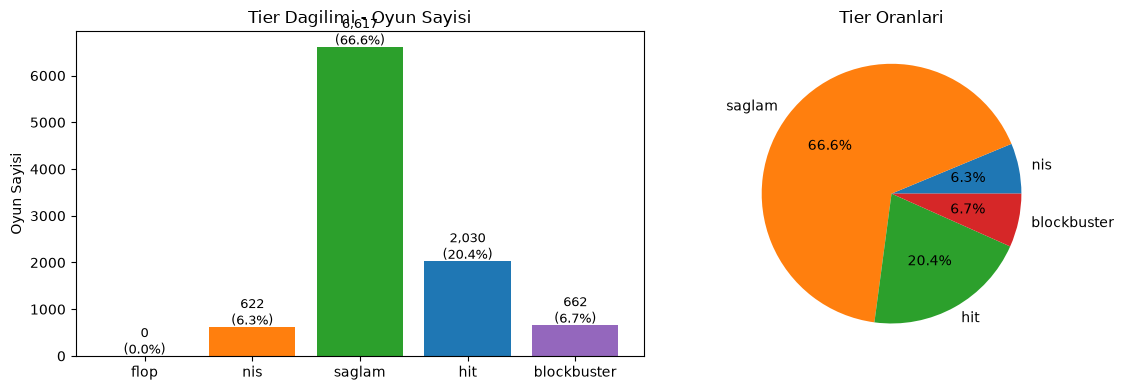

sales_tier
flop              0
nis             622
saglam         6617
hit            2030
blockbuster     662

Max/min sinif orani: 10.6x


In [2]:
tier_order = ["flop", "nis", "saglam", "hit", "blockbuster"]
tier_counts = df["sales_tier"].value_counts().reindex(tier_order, fill_value=0)
tier_pct    = (tier_counts / tier_counts.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ["#d62728","#ff7f0e","#2ca02c","#1f77b4","#9467bd"]
axes[0].bar(tier_order, tier_counts.values, color=colors)
axes[0].set_title("Tier Dagilimi - Oyun Sayisi")
axes[0].set_ylabel("Oyun Sayisi")
for i, (c, p) in enumerate(zip(tier_counts.values, tier_pct.values)):
    axes[0].text(i, c + 50, f"{c:,}\n({p}%)", ha="center", fontsize=9)

present = [t for t in tier_order if tier_counts[t] > 0]
axes[1].pie([tier_counts[t] for t in present], labels=present, autopct="%1.1f%%")
axes[1].set_title("Tier Oranlari")
plt.tight_layout()
plt.savefig("../data/ml/eda_tier_dist.png", dpi=120, bbox_inches="tight")
plt.show()
print(tier_counts.to_string())
print(f"\nMax/min sinif orani: {tier_counts.max() / tier_counts[tier_counts>0].min():.1f}x")


## 2. Feature Kapsama — Eksik Veri

=== Eksik Veri ===
  release_date null                 33  (0.3%)
  release_season None                0  (0.0%)
  dev_track_record null          6,407  (64.5%)
  has_track_record=1             3,524  (35.5%)
  has_track_record=0             6,407  (64.5%)


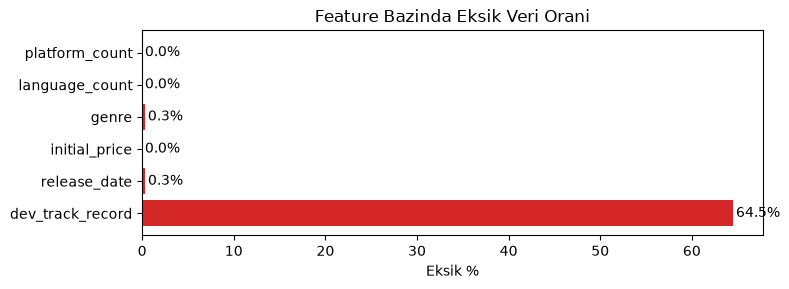

In [3]:
print("=== Eksik Veri ===")
items = {
    "release_date null":     df["release_date"].isna().sum(),
    "release_season None":   (df["release_season"] == "None").sum(),
    "dev_track_record null": df["dev_track_record"].isna().sum(),
    "has_track_record=1":    int(df["has_track_record"].sum()),
    "has_track_record=0":    int((df["has_track_record"]==0).sum()),
}
for k, v in items.items():
    print(f"  {k:<30} {v:>5,}  ({v/len(df)*100:.1f}%)")

cols_check = ["dev_track_record","release_date","initial_price","genre","language_count","platform_count"]
null_pcts = [df[c].isna().mean()*100 for c in cols_check]
fig, ax = plt.subplots(figsize=(8,3))
bars = ax.barh(cols_check, null_pcts, color="#d62728")
ax.set_xlabel("Eksik %")
ax.set_title("Feature Bazinda Eksik Veri Orani")
for bar, pct in zip(bars, null_pcts):
    ax.text(max(pct+0.3, 0.3), bar.get_y()+bar.get_height()/2, f"{pct:.1f}%", va="center")
plt.tight_layout()
plt.savefig("../data/ml/eda_missing.png", dpi=120, bbox_inches="tight")
plt.show()


## 3. Kaba Sinyal Kontrolu
Box plot: initial_price, language_count, platform_count, dev_track_record vs tier.  
Gorme hedefi: bu degiskenler tier'lari ayiriyor mu?

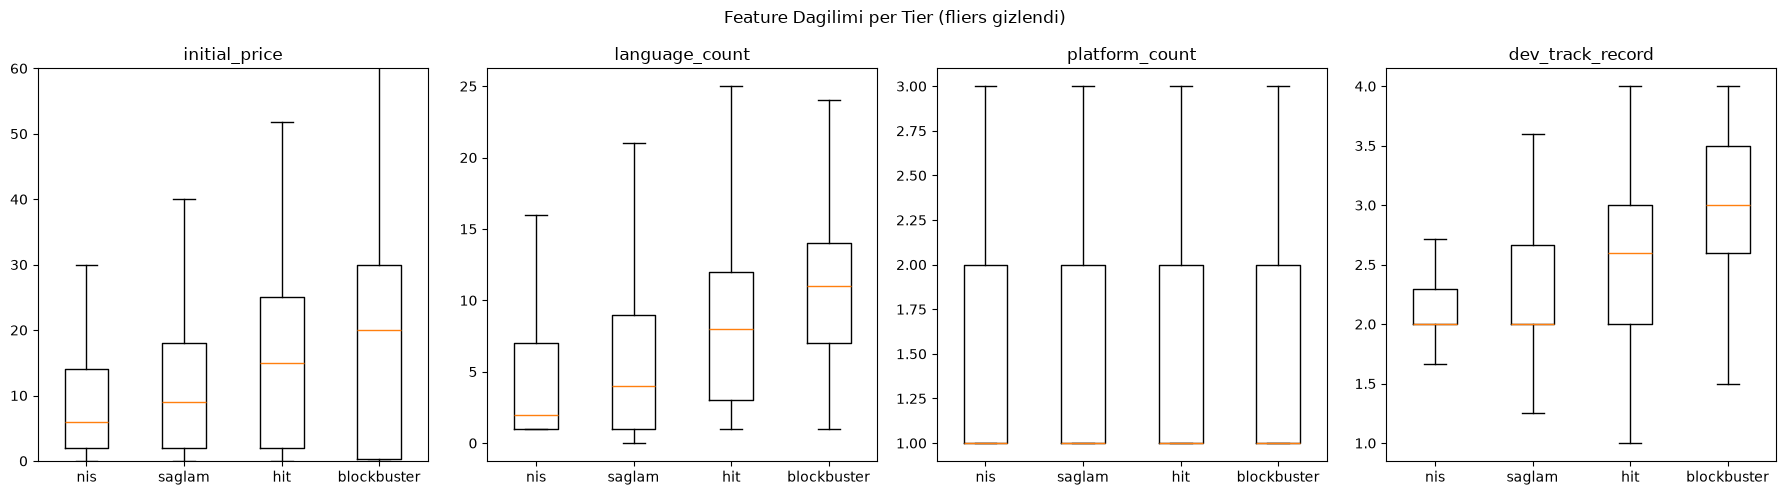

In [4]:
tier_present = [t for t in ["nis","saglam","hit","blockbuster"] if t in df["sales_tier"].values]
feats = ["initial_price", "language_count", "platform_count", "dev_track_record"]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, feat in zip(axes, feats):
    data = [df[df["sales_tier"]==t][feat].dropna().values for t in tier_present]
    ax.boxplot(data, tick_labels=tier_present, showfliers=False)
    ax.set_title(feat)
    if feat == "initial_price":
        ax.set_ylim(0, 60)
plt.suptitle("Feature Dagilimi per Tier (fliers gizlendi)")
plt.tight_layout()
plt.savefig("../data/ml/eda_feature_boxplots.png", dpi=120, bbox_inches="tight")
plt.show()


## 4. Top Tag — Tier Iliskisi

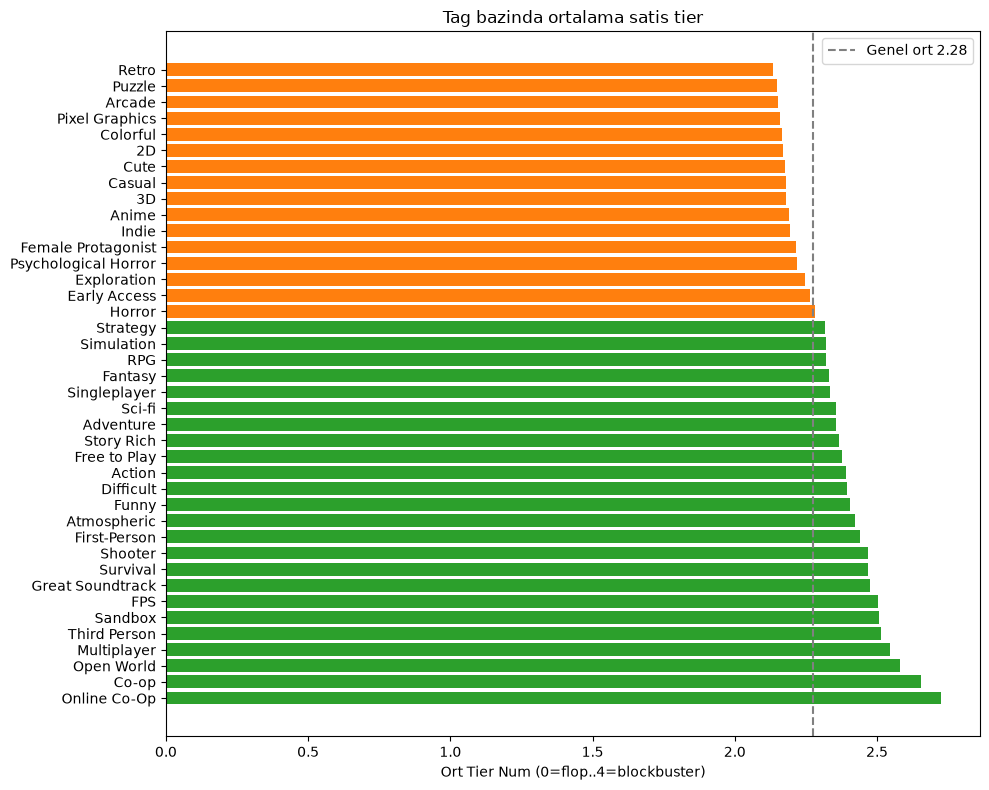

Yuksek tier tagler (>2.3): ['Online Co-Op', 'Co-op', 'Open World', 'Multiplayer', 'Third Person', 'Sandbox', 'FPS', 'Great Soundtrack', 'Survival', 'Shooter', 'First-Person', 'Atmospheric', 'Funny', 'Difficult', 'Action', 'Free to Play', 'Story Rich', 'Adventure', 'Sci-fi', 'Singleplayer', 'Fantasy', 'RPG', 'Simulation', 'Strategy']
Dusuk tier tagler (<2.0): []


In [5]:
tag_cols = [c for c in df.columns if c.startswith("tag_")]
tag_avg = {}
for col in tag_cols:
    mask = df[col] == 1
    if mask.sum() > 50:
        name = col.replace("tag_", "").replace("_", " ")
        tag_avg[name] = df.loc[mask, "tier_num"].mean()

ts = pd.Series(tag_avg).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#2ca02c" if v>=2.3 else ("#ff7f0e" if v>=2.0 else "#d62728") for v in ts.values]
ax.barh(ts.index, ts.values, color=colors)
ax.axvline(df["tier_num"].mean(), color="gray", ls="--",
           label=f"Genel ort {df['tier_num'].mean():.2f}")
ax.set_xlabel("Ort Tier Num (0=flop..4=blockbuster)")
ax.set_title("Tag bazinda ortalama satis tier")
ax.legend()
plt.tight_layout()
plt.savefig("../data/ml/eda_tag_tier.png", dpi=120, bbox_inches="tight")
plt.show()
print("Yuksek tier tagler (>2.3):", ts[ts>2.3].index.tolist())
print("Dusuk tier tagler (<2.0):",  ts[ts<2.0].index.tolist())


## 5. Developer Track Record Dagilimi

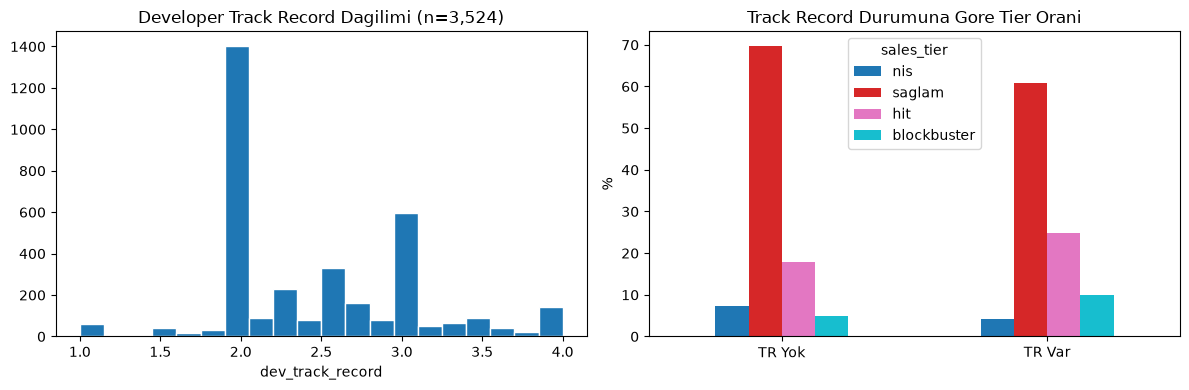

TR var  - ort tier: 2.41
TR yok  - ort tier: 2.20


In [6]:
tr = df[df["has_track_record"]==1]["dev_track_record"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tr, bins=20, color="#1f77b4", edgecolor="white")
axes[0].set_xlabel("dev_track_record")
axes[0].set_title(f"Developer Track Record Dagilimi (n={len(tr):,})")

tier_present = [t for t in ["nis","saglam","hit","blockbuster"] if t in df["sales_tier"].values]
grp = df.groupby(["has_track_record","sales_tier"]).size().unstack(fill_value=0)
grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
grp_pct.index = ["TR Yok","TR Var"]
grp_pct[tier_present].plot(kind="bar", ax=axes[1], colormap="tab10")
axes[1].set_title("Track Record Durumuna Gore Tier Orani")
axes[1].set_ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/ml/eda_track_record.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"TR var  - ort tier: {df[df['has_track_record']==1]['tier_num'].mean():.2f}")
print(f"TR yok  - ort tier: {df[df['has_track_record']==0]['tier_num'].mean():.2f}")


## 6. Final Tablo Ozeti

In [7]:
print("=== features.parquet Ozeti ===")
print(f"Satir: {len(df):,}")
print(f"Toplam kolon: {df.shape[1]}")
tag_count = len([c for c in df.columns if c.startswith("tag_")])
print(f"  Tag multi-hot kolonlar: {tag_count}")
print(f"  Temel feature'lar: initial_price, genre, release_season, "
      f"language_count, platform_count, dev_track_record, dev_prior_game_count, has_track_record")
print(f"  Sandbox (modele girmesin): owners_*, positive, negative, positive_ratio")
print()
tier_order = ["flop","nis","saglam","hit","blockbuster"]
print("Tier dagilimi (final):")
print(df["sales_tier"].value_counts().reindex(tier_order, fill_value=0).to_string())


=== features.parquet Ozeti ===
Satir: 9,931
Toplam kolon: 61
  Tag multi-hot kolonlar: 40
  Temel feature'lar: initial_price, genre, release_season, language_count, platform_count, dev_track_record, dev_prior_game_count, has_track_record
  Sandbox (modele girmesin): owners_*, positive, negative, positive_ratio

Tier dagilimi (final):
sales_tier
flop              0
nis             622
saglam         6617
hit            2030
blockbuster     662


## Asama 2 Notlari

- **Sinif dengesizligi**: `saglam` ~%67. Stratified split + class_weight=balanced ya da SMOTE onerilir.
- **flop sinifi bos**: SteamSpy veri 50k altini kapsamiyor. 4-sinif sisteme gecilebilir (flop'u dusur).
- **dev_track_record**: ~%35 kapsama — `has_track_record` bayragi modele feature olmali.
- **Encoding**: genre + release_season kategorik → one-hot ya da LightGBM native cat.
- **Metrik**: Macro-F1 (accuracy aldatici). Ek: confusion matrix + SHAP.